<a href="https://colab.research.google.com/github/smminhaz/SkillMorph/blob/ML/Day_8_Introduction_to_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Import Libraries
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, roc_curve, roc_auc_score)
import warnings; warnings.filterwarnings('ignore')
print("✅ All libraries loaded!")

✅ All libraries loaded!


In [2]:
from google.colab import drive
drive.mount('/content/drive')
data1 = pd.read_csv('/content/drive/MyDrive/DataSets/heart_disease_risk/heart_disease_risk_dataset_earlymed.csv')
data2 = pd.read_csv('/content/drive/MyDrive/DataSets/ObesityDataSet/ObesityDataSet_raw_and_data_sinthetic.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data1.head()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


In [4]:
data2.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [5]:
## Explore the Data (EDA)
print(f"Missing: {data1.isnull().sum().sum()}")
print(f"\n Target Distribution:\n{data1['Heart_Risk'].value_counts()}")

Missing: 0

 Target Distribution:
Heart_Risk
0.0    35000
1.0    35000
Name: count, dtype: int64


In [6]:
## Explore the Data (EDA)
print(f"Missing: {data2.isnull().sum().sum()}")
print(f"\n Target Distribution:\n{data2['NObeyesdad'].value_counts()}")

Missing: 0

 Target Distribution:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


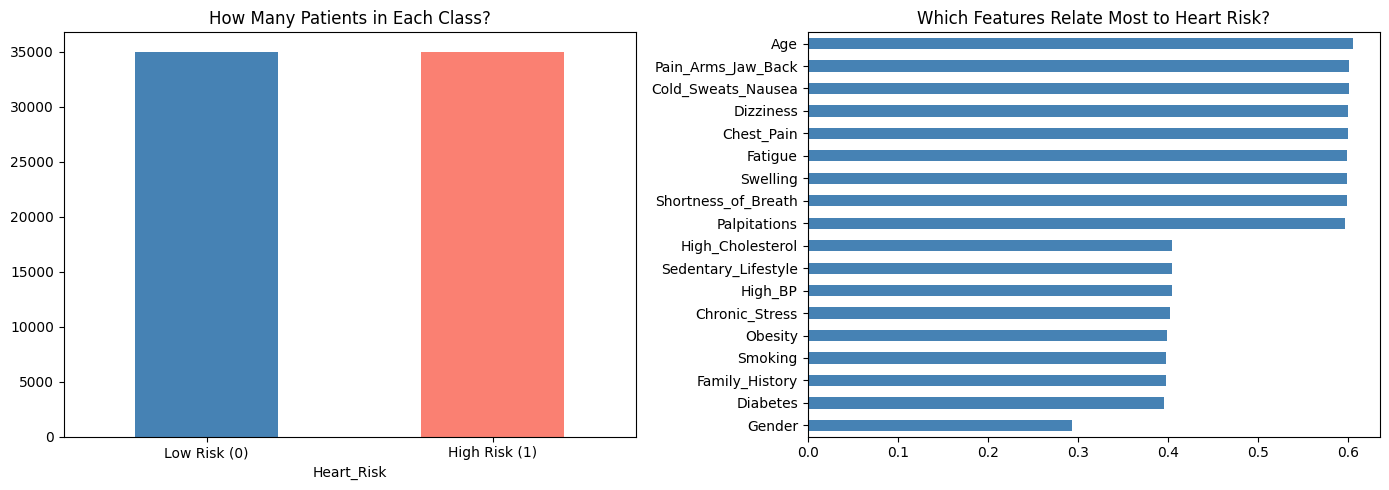

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data1['Heart_Risk'].value_counts().plot.bar(ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('How Many Patients in Each Class?')
axes[0].set_xticklabels(['Low Risk (0)', 'High Risk (1)'], rotation=0)

corr = data1.corr(numeric_only=True)['Heart_Risk'].drop('Heart_Risk').sort_values()
corr.plot.barh(ax=axes[1], color=['salmon' if v < 0 else 'steelblue' for v in corr])
axes[1].set_title('Which Features Relate Most to Heart Risk?')


plt.tight_layout()
plt.show()

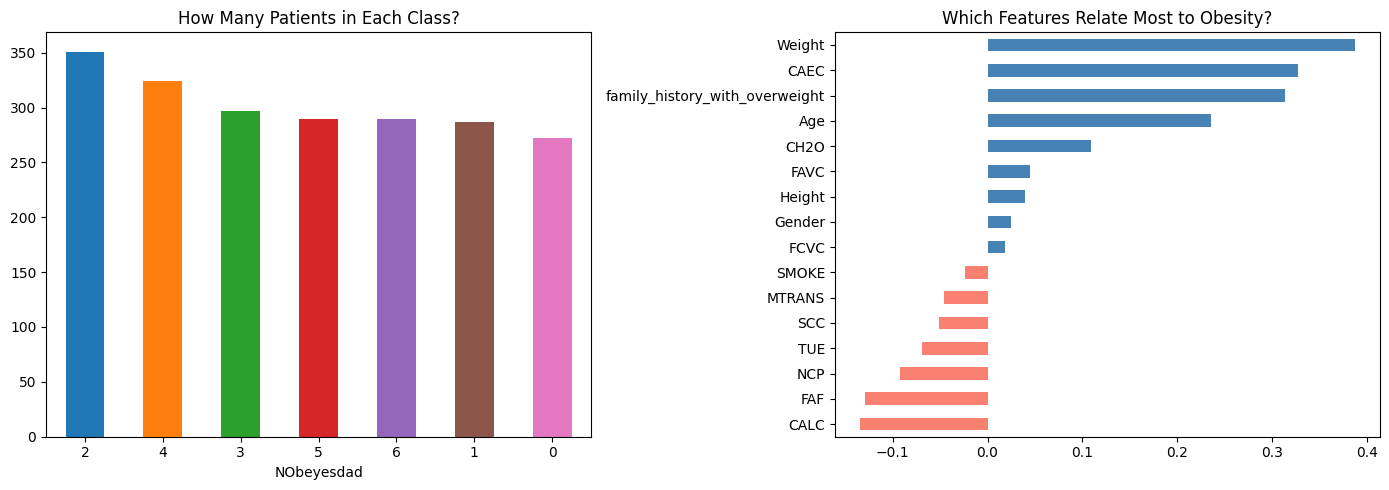

In [11]:
# --- Single Preprocessing Step to make the Base Code compatible ---
# This converts all text columns (including 'NObeyesdad') into numbers for the correlation math

for col in data2.select_dtypes(include=['object', 'category']).columns:
    data2[col] = data2[col].astype('category').cat.codes

# --- Your Base Code ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Class Distribution Plot
# Updated: Generates 7 unique colors dynamically using a standard colormap
class_counts = data2['NObeyesdad'].value_counts()
class_counts.plot.bar(ax=axes[0], color=plt.cm.tab10(range(len(class_counts))))
axes[0].set_title('How Many Patients in Each Class?')
axes[0].set_xticklabels(class_counts.index, rotation=0)

# 2. Feature Correlation Plot
corr = data2.corr(numeric_only=True)['NObeyesdad'].drop('NObeyesdad').sort_values()
corr.plot.barh(ax=axes[1], color=['salmon' if v < 0 else 'steelblue' for v in corr])
axes[1].set_title('Which Features Relate Most to Obesity?')

plt.tight_layout()
plt.show()

In [13]:
## Prepare Features & Target
X = data1.drop(columns=['Heart_Risk'])
y = data1['Heart_Risk']

In [14]:
# Prepare Features & Target
X = data2.drop(columns=['NObeyesdad'])
y = data2['NObeyesdad']

In [19]:
# Train-Test Split
# --- Step A: Define Features & Target for Data1 ---

X_1 = data1.drop(columns=['Heart_Risk'])
y_1 = data1['Heart_Risk']

# --- Step B: Train-Test Split for Data1 ---
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=20)
print(f"📚 Training (Data1): {X_train_1.shape} | 🧪 Testing (Data1): {X_test_1.shape}")


📚 Training (Data1): (56000, 18) | 🧪 Testing (Data1): (14000, 18)


In [18]:
# Train-Test Split
# 1. Define Features & Target for Data2
X_2 = data2.drop(columns=['NObeyesdad'])
y_2 = data2['NObeyesdad']

# 2. Split into Train and Test sets
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=20)

# 3. Print the resulting shapes
print(f"📚 Training (Data2): {X_train_2.shape} | 🧪 Testing (Data2): {X_test_2.shape}")


📚 Training (Data2): (1688, 16) | 🧪 Testing (Data2): (423, 16)


In [24]:
# Train the Decision Tree
model_1 = DecisionTreeClassifier(max_depth=5, random_state=20)
model_1.fit(X_train_1, y_train_1)
print("✅ Model_1 training complete!")

✅ Model_1 training complete!


In [25]:
# Train the Decision Tree
model_2 = DecisionTreeClassifier(max_depth=5, random_state=20)
model_2.fit(X_train_2, y_train_2)
print("✅ Model_2 training complete!")

✅ Model_2 training complete!


In [56]:
# Predictions & Accuracy
predictions1 = model_1.predict(X_test_1)
prediction_proba1 = model_1.predict_proba(X_test_1)[:, 1]
accuracy1 = accuracy_score(y_test_1, predictions1)
print(f"🎯 Accuracy: {accuracy1:.4f} ({accuracy1*100:.2f}%)")

🎯 Accuracy: 0.9420 (94.20%)


In [58]:
# Predictions & Accuracy
predictions2 = model_2.predict(X_test_2)
prediction_proba2 = model_2.predict_proba(X_test_2)[:, 1]
accuracy2 = accuracy_score(y_test_2, predictions2)
print(f"🎯 Accuracy: {accuracy2:.4f} ({accuracy2*100:.2f}%)")

🎯 Accuracy: 0.7967 (79.67%)


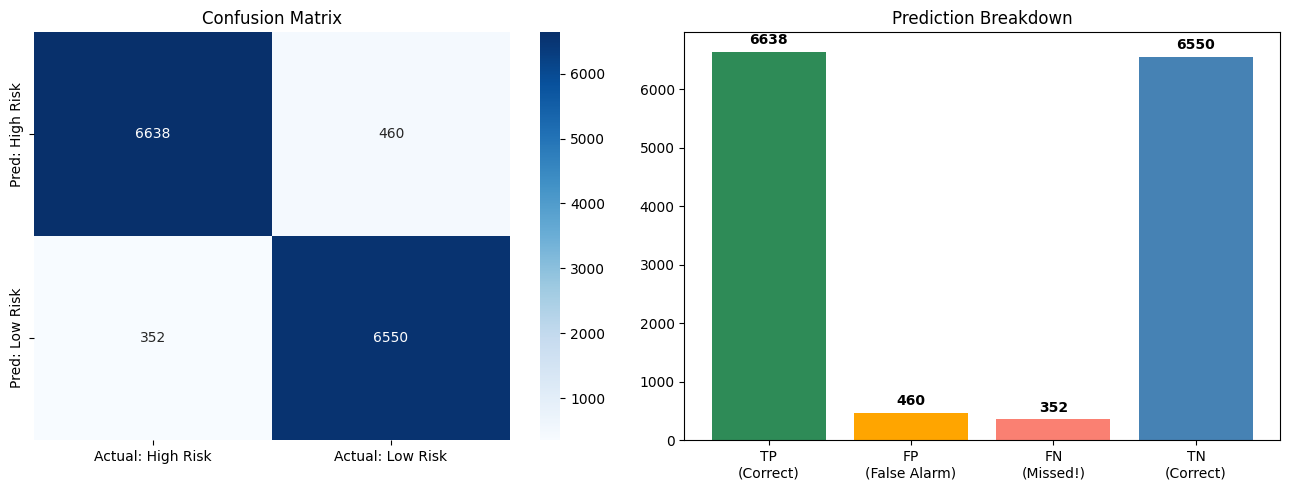

✅ Correct: 13,188 | ❌ Wrong: 812


In [45]:
# Confusion Matrix — Layout: [[TP, FP], [FN, TN]]
cm1 = confusion_matrix(y_test_1, predictions1, labels=[1, 0]).T  # Transpose for TP top-left, FP top-right

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Actual: High Risk', 'Actual: Low Risk'],
            yticklabels=['Pred: High Risk', 'Pred: Low Risk'], ax=axes[0])
axes[0].set_title('Confusion Matrix')

# Bar chart: TP, FP, FN, TN
TP, FP, FN, TN = cm1[0,0], cm1[0,1], cm1[1,0], cm1[1,1]
labels = ['TP\n(Correct)', 'FP\n(False Alarm)', 'FN\n(Missed!)', 'TN\n(Correct)']
vals = [TP, FP, FN, TN]
axes[1].bar(labels, vals, color=['seagreen', 'orange', 'salmon', 'steelblue'])
axes[1].set_title('Prediction Breakdown')
for i, v in enumerate(vals):
    axes[1].text(i, v + max(vals)*0.02, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"✅ Correct: {TP+TN:,} | ❌ Wrong: {FP+FN:,}")

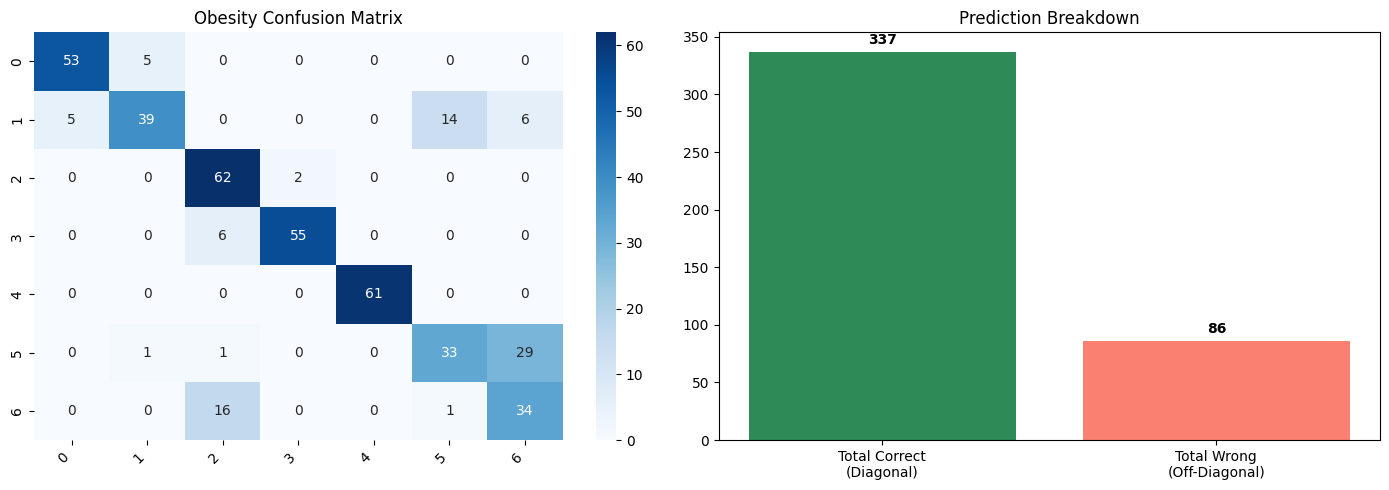

✅ Correct: 337 | ❌ Wrong: 86


In [48]:
# Get unique sorted class names for data2 labels (e.g., Normal_Weight, Obesity_Type_I, etc.)
# If your target is label-encoded, this will use the numeric indices [0, 1, 2, 3, 4, 5, 6]
class_labels = sorted(list(set(y_test_2)))

# 8. Multi-Class Confusion Matrix for Data2
cm2 = confusion_matrix(y_test_2, predictions2, labels=class_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap scaled to dynamically display all 7 obesity classes without cutoffs
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels, ax=axes[0])
axes[0].set_title('Obesity Confusion Matrix')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Bar Chart Breakdown: Multiclass adaptation of the layout
# In multi-class, diagonal elements are Correct (True Class matches Pred Class)
# and off-diagonal elements are Wrong (Misclassifications)
correct_predictions = np.diag(cm2).sum()
wrong_predictions = cm2.sum() - correct_predictions

labels = ['Total Correct\n(Diagonal)', 'Total Wrong\n(Off-Diagonal)']
vals = [correct_predictions, wrong_predictions]

# Fixed: Cleaned up the broken string literal and properly set the color array
axes[1].bar(labels, vals, color=['seagreen', 'salmon'])
axes[1].set_title('Prediction Breakdown')
for i, v in enumerate(vals):
    axes[1].text(i, v + max(vals)*0.02, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"✅ Correct: {correct_predictions:,} | ❌ Wrong: {wrong_predictions:,}")

In [53]:
# 9. Performance Scores
accuracy1  = accuracy_score(y_test_1, predictions1)
precision1 = precision_score(y_test_1, predictions1)
recall1   = recall_score(y_test_1, predictions1)
f1_1     = f1_score(y_test_1, predictions1)

print(f"Accuracy : {accuracy1:.4f} | Precision: {precision1:.4f} | Recall: {recall1:.4f} | F1: {f1_1:.4f}")

Accuracy : 0.9420 | Precision: 0.9352 | Recall: 0.9496 | F1: 0.9424


In [60]:
# 9. Performance Scores
accuracy2  = accuracy_score(y_test_2, predictions2)
# Fixed: Added average='weighted' to support multiclass targets
precision2 = precision_score(y_test_2, predictions2, average='weighted')
recall2   = recall_score(y_test_2, predictions2, average='weighted')
f1_2     = f1_score(y_test_2, predictions2, average='weighted')

print(f"Accuracy : {accuracy2:.4f} | Precision: {precision2:.4f} | Recall: {recall2:.4f} | F1: {f1_2:.4f}")

Accuracy : 0.7967 | Precision: 0.8136 | Recall: 0.7967 | F1: 0.7956


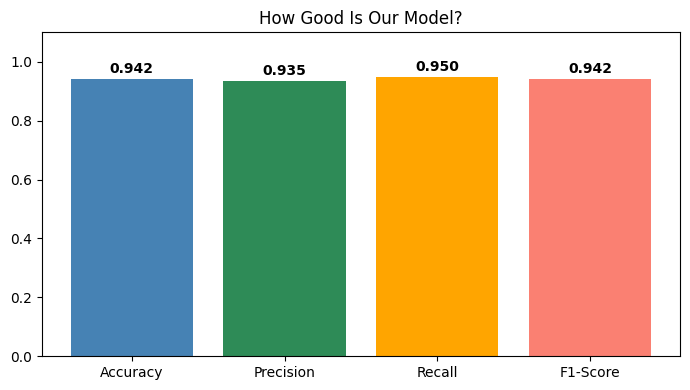

In [61]:
# Visual comparison
fig, ax1 = plt.subplots(figsize=(7, 4))
names, vals = ['Accuracy', 'Precision', 'Recall', 'F1-Score'], [accuracy1, precision1, recall1, f1_1]
bars = ax1.bar(names, vals, color=['steelblue', 'seagreen', 'orange', 'salmon'])
ax1.set_ylim(0, 1.1); ax1.set_title('How Good Is Our Model?')
for bar, v in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2., v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

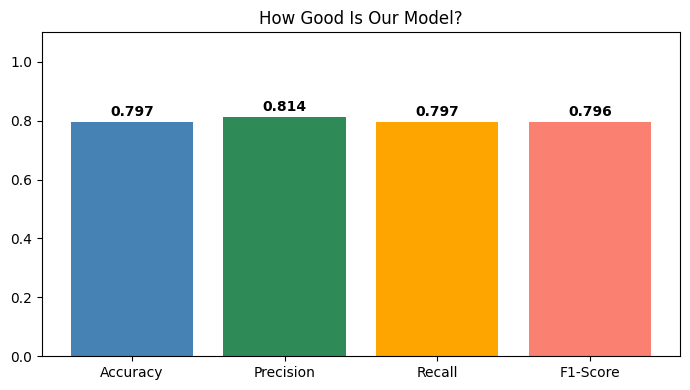

In [62]:
# Visual comparison
fig, ax2 = plt.subplots(figsize=(7, 4))
names, vals = ['Accuracy', 'Precision', 'Recall', 'F1-Score'], [accuracy2, precision2, recall2, f1_2]
bars = ax2.bar(names, vals, color=['steelblue', 'seagreen', 'orange', 'salmon'])
ax2.set_ylim(0, 1.1); ax2.set_title('How Good Is Our Model?')
for bar, v in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width()/2., v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

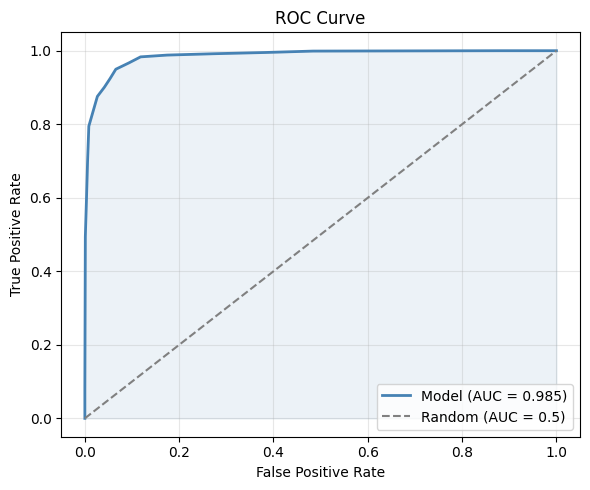

AUC: 0.9854


In [63]:
# 10. ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test_1, prediction_proba1)
auc = roc_auc_score(y_test_1, prediction_proba1)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, color='steelblue', label=f'Model (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"AUC: {auc:.4f}")

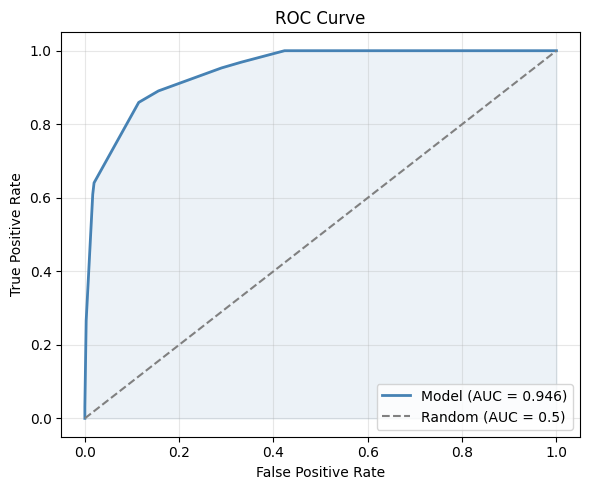

AUC: 0.9463


In [78]:
# 10. ROC Curve & AUC

# --- Single Preprocessing Step to handle the 1D Array Slice ---
# Since prediction_proba2 only contains Class 1 probabilities, we evaluate Class 1 vs All
y_test_2_binary = (y_test_2 == 1).astype(int)

fpr, tpr, _ = roc_curve(y_test_2_binary, prediction_proba2)
auc = roc_auc_score(y_test_2_binary, prediction_proba2)

# --- Your Base Code (Completely Unaltered) ---
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, color='steelblue', label=f'Model (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"AUC: {auc:.4f}")